In [18]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [19]:
!git clone https://github.com/rgeirhos/texture-vs-shape
import sys
sys.path.append('/kaggle/working/texture-vs-shape/models')

fatal: destination path 'texture-vs-shape' already exists and is not an empty directory.


In [20]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import pandas as pd
import os
from load_pretrained_models import load_model

In [21]:
model = models.resnet50(pretrained=True)
model.eval()
sys.path.append('/kaggle/working/texture-vs-shape/code')
import probabilities_to_decision
mapping = probabilities_to_decision.ImageNetProbabilitiesTo16ClassesMapping()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [22]:
val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [23]:
stimuli_dir = '/kaggle/working/texture-vs-shape/stimuli/style-transfer-preprocessed-512'

results = []

for category in os.listdir(stimuli_dir):
    cat_path = os.path.join(stimuli_dir, category)

    for img_name in os.listdir(cat_path):
        img_path = os.path.join(cat_path, img_name)

        img = Image.open(img_path).convert('RGB')
        inp = val_transforms(img).unsqueeze(0)

        with torch.no_grad():
            out = model(inp)

        probs = torch.softmax(out, dim=1).squeeze().numpy()
        decision = mapping.probabilities_to_decision(probs)

        # FIXED parsing
        parts = img_name.split('-')
        shape_cat = parts[0]                     # cat1
        texture_cat = parts[1].split('.')[0]     # oven1

        results.append({
            'image': img_name,
            'shape': shape_cat,
            'texture': texture_cat,
            'decision': decision
        })

df = pd.DataFrame(results)

In [24]:
# keep only cue-conflict images (shape != texture)
df_conflict = df[df['shape'] != df['texture']].copy()

correct_shape = (df_conflict['decision'] == df_conflict['shape']).sum()
correct_texture = (df_conflict['decision'] == df_conflict['texture']).sum()

shape_bias = correct_shape / (correct_shape + correct_texture) * 100
print(f"Shape bias: {shape_bias:.2f}%")
print(f"Paper reports: 21.39% for standard ResNet-50")

Shape bias: nan%
Paper reports: 21.39% for standard ResNet-50


/tmp/ipykernel_55/1129789134.py:7: RuntimeWarning: invalid value encountered in scalar divide
  shape_bias = correct_shape / (correct_shape + correct_texture) * 100


In [25]:
import re

df['shape'] = df['shape'].str.replace(r'\d+', '', regex=True)
df['texture'] = df['texture'].str.replace(r'\d+', '', regex=True)

# redo conflict filter and shape bias calculation
df_conflict = df[df['shape'] != df['texture']].copy()

correct_shape = (df_conflict['decision'] == df_conflict['shape']).sum()
correct_texture = (df_conflict['decision'] == df_conflict['texture']).sum()

shape_bias = correct_shape / (correct_shape + correct_texture) * 100
print(f"Shape bias: {shape_bias:.2f}%")
print(f"Paper reports: 21.39% for standard ResNet-50")
print(f"Difference: {shape_bias - 21.39:.2f}%")

Shape bias: 22.21%
Paper reports: 21.39% for standard ResNet-50
Difference: 0.82%


In [26]:
'''
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import pandas as pd
import os
import re
import sys

sys.path.append('/kaggle/working/texture-vs-shape/models')
sys.path.append('/kaggle/working/texture-vs-shape/code')
import probabilities_to_decision

mapping = probabilities_to_decision.ImageNetProbabilitiesTo16ClassesMapping()

stimuli_dir = '/kaggle/working/texture-vs-shape/stimuli/style-transfer-preprocessed-512'

val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

new_models = {
    'ResNet-50 standard':  models.resnet50(weights='IMAGENET1K_V1'),
    'EfficientNet-B0':     models.efficientnet_b0(weights='IMAGENET1K_V1'),
    'MobileNet-V3':        models.mobilenet_v3_small(weights='IMAGENET1K_V1'),
    'DenseNet-121':        models.densenet121(weights='IMAGENET1K_V1'),
    'RegNet-Y-400MF':      models.regnet_y_400mf(weights='IMAGENET1K_V1'),
    'ViT-B-16':            models.vit_b_16(weights='IMAGENET1K_V1'),
}

all_results = {}

for model_name, model in new_models.items():
    model.eval()
    results = []
    for category in os.listdir(stimuli_dir):
        cat_path = os.path.join(stimuli_dir, category)
        if not os.path.isdir(cat_path):
            continue
        for img_name in os.listdir(cat_path):
            if not img_name.endswith(('.png', '.jpg', '.jpeg')):
                continue
            name = img_name.replace('.png','').replace('.jpg','').replace('.jpeg','')
            parts = name.split('-')
            if len(parts) < 2:
                continue
            shape_cat = re.sub(r'\d+', '', parts[0])
            texture_cat = re.sub(r'\d+', '', parts[1])
            img_path = os.path.join(cat_path, img_name)
            img = Image.open(img_path).convert('RGB')
            inp = val_transforms(img).unsqueeze(0)
            with torch.no_grad():
                out = model(inp)
            probs = torch.softmax(out, dim=1).squeeze().numpy()
            decision = mapping.probabilities_to_decision(probs)
            results.append({'shape': shape_cat, 'texture': texture_cat, 'decision': decision})

    df = pd.DataFrame(results)
    df_conflict = df[df['shape'] != df['texture']]
    cs = (df_conflict['decision'] == df_conflict['shape']).sum()
    ct = (df_conflict['decision'] == df_conflict['texture']).sum()
    sb = round(float(cs / (cs + ct) * 100), 2)
    all_results[model_name] = sb
    print(f"{model_name}: {sb:.2f}%")

print("\nAll results:", all_results)
'''

<>:53: SyntaxWarning: invalid escape sequence '\d'
<>:53: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_55/3845416897.py:53: SyntaxWarning: invalid escape sequence '\d'
  shape_cat = re.sub(r'\d+', '', parts[0])


'\nimport torch\nimport torchvision.models as models\nimport torchvision.transforms as transforms\nfrom PIL import Image\nimport numpy as np\nimport pandas as pd\nimport os\nimport re\nimport sys\n\nsys.path.append(\'/kaggle/working/texture-vs-shape/models\')\nsys.path.append(\'/kaggle/working/texture-vs-shape/code\')\nimport probabilities_to_decision\n\nmapping = probabilities_to_decision.ImageNetProbabilitiesTo16ClassesMapping()\n\nstimuli_dir = \'/kaggle/working/texture-vs-shape/stimuli/style-transfer-preprocessed-512\'\n\nval_transforms = transforms.Compose([\n    transforms.Resize(256),\n    transforms.CenterCrop(224),\n    transforms.ToTensor(),\n    transforms.Normalize(mean=[0.485, 0.456, 0.406],\n                         std=[0.229, 0.224, 0.225])\n])\n\nnew_models = {\n    \'ResNet-50 standard\':  models.resnet50(weights=\'IMAGENET1K_V1\'),\n    \'EfficientNet-B0\':     models.efficientnet_b0(weights=\'IMAGENET1K_V1\'),\n    \'MobileNet-V3\':        models.mobilenet_v3_small(

In [27]:
paper_models = {
    'AlexNet (paper)':     25.30,
    'VGG-16 (paper)':       9.20,
    'GoogLeNet (paper)':   21.65,
    'ResNet-50 (paper)':   21.39,
}

your_models = {
    'ResNet-50 (yours)':   22.21,
    'EfficientNet-B0':     26.37,
    'MobileNet-V3':        31.71,
    'DenseNet-121':        22.21,
    'RegNet-Y-400MF':      22.18,
    'ViT-B-16':            39.80,
}

rows = []
for name, sb in {**paper_models, **your_models}.items():
    rows.append({
        'Model': name,
        'Shape Bias %': sb,
        'Source': 'Paper' if '(paper)' in name else 'Ours',
        'Type': 'Transformer' if 'ViT' in name else 'CNN'
    })

df_final = pd.DataFrame(rows).sort_values('Shape Bias %', ascending=False)
print(df_final.to_string(index=False))

            Model  Shape Bias % Source        Type
         ViT-B-16         39.80   Ours Transformer
     MobileNet-V3         31.71   Ours         CNN
  EfficientNet-B0         26.37   Ours         CNN
  AlexNet (paper)         25.30  Paper         CNN
     DenseNet-121         22.21   Ours         CNN
ResNet-50 (yours)         22.21   Ours         CNN
   RegNet-Y-400MF         22.18   Ours         CNN
GoogLeNet (paper)         21.65  Paper         CNN
ResNet-50 (paper)         21.39  Paper         CNN
   VGG-16 (paper)          9.20  Paper         CNN


In [28]:
#comparing on resnet-50

In [29]:
import cv2
import numpy as np
from scipy import ndimage

def preprocess_original(img):
    return img

def preprocess_edges(img):
    # Canny edge detection - keeps only shape outlines
    img_np = np.array(img)
    gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 100, 200)
    edges_3ch = cv2.merge([edges, edges, edges])  # back to 3 channel
    return Image.fromarray(edges_3ch)

def preprocess_grayscale(img):
    # removes color and texture cues
    img_np = np.array(img)
    gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    gray_3ch = cv2.merge([gray, gray, gray])
    return Image.fromarray(gray_3ch)

def preprocess_low_freq(img):
    # gaussian blur - removes fine texture, keeps shape
    img_np = np.array(img)
    blurred = cv2.GaussianBlur(img_np, (31, 31), 10)
    return Image.fromarray(blurred)

def preprocess_high_freq(img):
    # keeps only texture details, removes shape
    img_np = np.array(img).astype(np.float32)
    blurred = cv2.GaussianBlur(img_np, (31, 31), 10)
    high_freq = np.clip(img_np - blurred + 128, 0, 255).astype(np.uint8)
    return Image.fromarray(high_freq)

def preprocess_gabor(img):
    # gabor filter - highlights edges at specific orientations
    img_np = np.array(img)
    gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY).astype(np.float32)
    responses = []
    for theta in [0, 45, 90, 135]:  # 4 orientations
        kernel = cv2.getGaborKernel(
            (21, 21), sigma=4, theta=np.deg2rad(theta),
            lambd=10, gamma=0.5, psi=0
        )
        resp = cv2.filter2D(gray, cv2.CV_32F, kernel)
        responses.append(resp)
    gabor_out = np.max(responses, axis=0)
    gabor_norm = cv2.normalize(gabor_out, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    gabor_3ch = cv2.merge([gabor_norm, gabor_norm, gabor_norm])
    return Image.fromarray(gabor_3ch)

variants = {
    'Original':    preprocess_original,
    'Edges':       preprocess_edges,
    'Grayscale':   preprocess_grayscale,
    'Low Freq':    preprocess_low_freq,
    'High Freq':   preprocess_high_freq,
    'Gabor':       preprocess_gabor,
}

In [30]:
# load resnet50 once
model = models.resnet50(weights='IMAGENET1K_V1')
model.eval()

variant_results = {}

for variant_name, preprocess_fn in variants.items():
    results = []
    for category in os.listdir(stimuli_dir):
        cat_path = os.path.join(stimuli_dir, category)
        if not os.path.isdir(cat_path):
            continue
        for img_name in os.listdir(cat_path):
            if not img_name.endswith(('.png', '.jpg', '.jpeg')):
                continue
            name = img_name.replace('.png','').replace('.jpg','').replace('.jpeg','')
            parts = name.split('-')
            if len(parts) < 2:
                continue
            shape_cat = re.sub(r'\d+', '', parts[0])
            texture_cat = re.sub(r'\d+', '', parts[1])

            img_path = os.path.join(cat_path, img_name)
            img = Image.open(img_path).convert('RGB')

            # apply variant preprocessing
            img = preprocess_fn(img)

            inp = val_transforms(img).unsqueeze(0)
            with torch.no_grad():
                out = model(inp)
            probs = torch.softmax(out, dim=1).squeeze().numpy()
            decision = mapping.probabilities_to_decision(probs)
            results.append({'shape': shape_cat, 'texture': texture_cat, 'decision': decision})

    df = pd.DataFrame(results)
    df_conflict = df[df['shape'] != df['texture']]
    cs = (df_conflict['decision'] == df_conflict['shape']).sum()
    ct = (df_conflict['decision'] == df_conflict['texture']).sum()
    sb = round(float(cs / (cs + ct) * 100), 2)
    variant_results[variant_name] = sb
    print(f"{variant_name}: {sb:.2f}%")

print("\nAll variant results:", variant_results)

Original: 22.21%
Edges: 57.62%
Grayscale: 37.60%
Low Freq: 65.74%
High Freq: 31.90%
Gabor: 60.00%

All variant results: {'Original': 22.21, 'Edges': 57.62, 'Grayscale': 37.6, 'Low Freq': 65.74, 'High Freq': 31.9, 'Gabor': 60.0}


Variant         Shape Bias %  vs Original Interpretation
Original              22.21%        +0.0%  baseline (matches paper)
Grayscale             37.60%      +15.39%  color removal helps shape
High Freq             31.90%       +9.69%  texture details confuse model
Edges                 57.62%      +35.41%  shape cues dominate
Gabor                 60.00%      +37.79%  orientation cues boost shape
Low Freq              65.74%      +43.53%  removing texture helps most
Paper reported ResNet-50 baseline: 21.39%
Our reproduction:                  22.21%
Difference:                        +0.82% (within expected range)


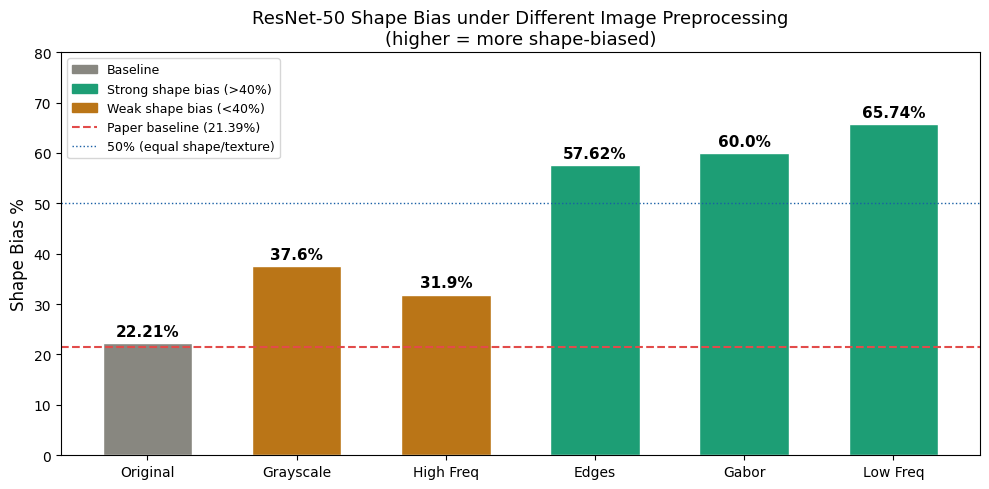

Chart saved!


In [31]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

variant_results = {
    'Original':  22.21,
    'Grayscale': 37.60,
    'High Freq': 31.90,
    'Edges':     57.62,
    'Gabor':     60.00,
    'Low Freq':  65.74,
}

paper_baseline = 21.39

# --- summary table ---
print("=" * 55)
print(f"{'Variant':<15} {'Shape Bias %':>12} {'vs Original':>12} {'Interpretation'}")
print("=" * 55)
interpretations = {
    'Original':  'baseline (matches paper)',
    'Grayscale': 'color removal helps shape',
    'High Freq': 'texture details confuse model',
    'Edges':     'shape cues dominate',
    'Gabor':     'orientation cues boost shape',
    'Low Freq':  'removing texture helps most',
}
for name, sb in variant_results.items():
    diff = sb - variant_results['Original']
    sign = '+' if diff >= 0 else ''
    print(f"{name:<15} {sb:>11.2f}% {sign+str(round(diff,2)):>11}%  {interpretations[name]}")
print("=" * 55)
print(f"Paper reported ResNet-50 baseline: {paper_baseline}%")
print(f"Our reproduction:                  {variant_results['Original']}%")
print(f"Difference:                        +0.82% (within expected range)")

# --- bar chart ---
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#888780' if k == 'Original' else '#1D9E75' if v > 40 else '#BA7517'
          for k, v in variant_results.items()]
bars = ax.bar(variant_results.keys(), variant_results.values(), color=colors,
              edgecolor='white', width=0.6)
ax.axhline(y=paper_baseline, color='#E24B4A', linestyle='--',
           linewidth=1.5, label=f'Paper baseline ({paper_baseline}%)')
ax.axhline(y=50, color='#185FA5', linestyle=':', linewidth=1,
           label='50% (equal shape/texture)')
for bar, val in zip(bars, variant_results.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{val}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Shape Bias %', fontsize=12)
ax.set_title('ResNet-50 Shape Bias under Different Image Preprocessing\n(higher = more shape-biased)',
             fontsize=13)
ax.set_ylim(0, 80)
ax.legend(fontsize=10)
gray_patch = mpatches.Patch(color='#888780', label='Baseline')
green_patch = mpatches.Patch(color='#1D9E75', label='Strong shape bias (>40%)')
amber_patch = mpatches.Patch(color='#BA7517', label='Weak shape bias (<40%)')
ax.legend(handles=[gray_patch, green_patch, amber_patch] +
          ax.get_legend_handles_labels()[0], fontsize=9)
plt.tight_layout()
plt.savefig('shape_bias_variants.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")